# Chest X-Ray Images (Pneumonia) Classification

In [21]:
import pandas as pd
import numpy as np
import os
import cv2
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [3]:
import warnings
warnings.filterwarnings("ignore")

## Exploraty Data Analysis and Data Preprocessing

In [4]:
labels=["NORMAL","PNEUMONIA"]
img_path="chest_xray/"

In [5]:
data = []

In [7]:
for split in ["train", "test", "val"]:
    for label in labels:
        folder_path = os.path.join(img_path, split, label)        
        if os.path.exists(folder_path):
            for file_name in os.listdir(folder_path):
                if file_name.endswith(('.jpeg', '.png', '.jpg')):
                    full_path = os.path.join(folder_path, file_name)
                    numeric_label = 0 if label == "NORMAL" else 1
                    data.append({"image_path": full_path, "label": numeric_label, "category": label})

In [8]:
df = pd.DataFrame(data)

In [9]:
df

,image_path,label,category
0,chest_xray/train\NORMAL\IM-0115-0001.jpeg,0,NORMAL
1,chest_xray/train\NORMAL\IM-0117-0001.jpeg,0,NORMAL
2,chest_xray/train\NORMAL\IM-0119-0001.jpeg,0,NORMAL
3,chest_xray/train\NORMAL\IM-0122-0001.jpeg,0,NORMAL
4,chest_xray/train\NORMAL\IM-0125-0001.jpeg,0,NORMAL
...,...,...,...
11707,chest_xray/val\PNEUMONIA\person1949_bacteria_4...,1,PNEUMONIA
11708,chest_xray/val\PNEUMONIA\person1950_bacteria_4...,1,PNEUMONIA
11709,chest_xray/val\PNEUMONIA\person1951_bacteria_4...,1,PNEUMONIA
11710,chest_xray/val\PNEUMONIA\person1952_bacteria_4...,1,PNEUMONIA


In [10]:
df.isnull().sum()

image_path    0
label         0
category      0
dtype: int64

In [12]:
x = []
for img_path in df["image_path"]:
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (128, 128))
    img = img / 255.0  
    x.append(img)

In [13]:
x = np.array(x, dtype=np.float32)
y = np.array(df["label"], dtype=np.int32)

# Model Training and Testing

In [15]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20,random_state=42,stratify=y)

In [18]:
model = Sequential()
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Ezberlemeyi (overfitting) önlemek için %50 nöron kapatma
    layers.Dense(1, activation='sigmoid') # İkili sınıflandırma (0: Normal, 1: Pneumonia)
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history=model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=10,batch_size=64,verbose=1)

Epoch 1/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 164s 1s/step - accuracy: 0.8901 - loss: 0.2663 - val_accuracy: 0.9445 - val_loss: 0.1535
Epoch 2/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 206s 1s/step - accuracy: 0.9447 - loss: 0.1515 - val_accuracy: 0.9590 - val_loss: 0.1132
Epoch 3/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 158s 1s/step - accuracy: 0.9588 - loss: 0.1132 - val_accuracy: 0.9612 - val_loss: 0.1070
Epoch 4/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 161s 1s/step - accuracy: 0.9630 - loss: 0.1035 - val_accuracy: 0.9646 - val_loss: 0.0879
Epoch 5/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 157s 1s/step - accuracy: 0.9685 - loss: 0.0864 - val_accuracy: 0.9710 - val_loss: 0.0789
Epoch 6/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 168s 1s/step - accuracy: 0.9736 - loss: 0.0695 - val_accuracy: 0.9748 - val_loss: 0.0766
Epoch 7/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 191s 1s/step - accuracy: 0.9747 - loss: 0.0649 - val_accuracy: 0.9791 - val_loss: 0.0574
Epoch 8/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.9811 - loss: 0.0450 - val_accu

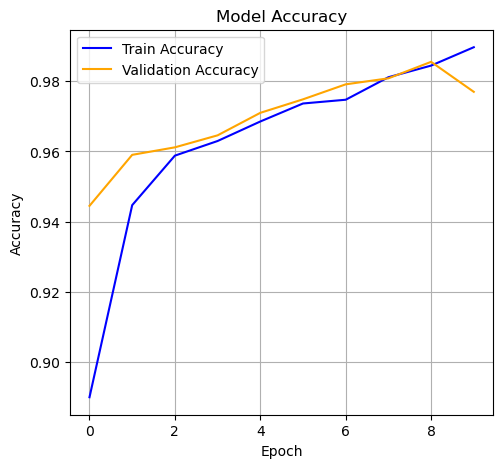

In [22]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

74/74 ━━━━━━━━━━━━━━━━━━━━ 12s 153ms/step


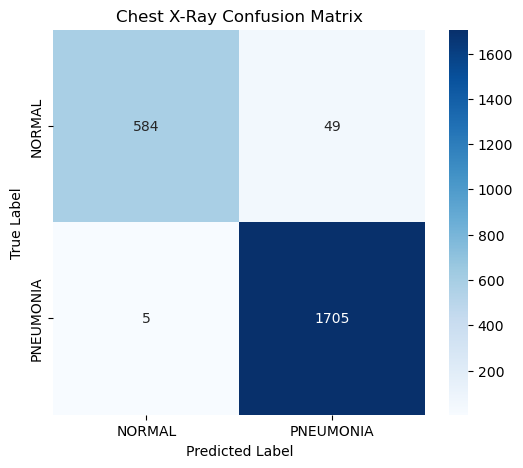

In [24]:
predictions = model.predict(x_test)
y_pred = (predictions > 0.5).astype(int)
class_names = ['NORMAL', 'PNEUMONIA']

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names
)

plt.title('Chest X-Ray Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [25]:
model.save("chest_xray_model.keras")